利用拉氏变换解初值问题
$$
\begin{cases}
y^{(4)} + 2 y'' + y = 4 t e^t, \\
y(0) = y'(0) = y''(0) = y^{(3)}(0) = 0.
\end{cases}
$$

**解** 设 $\mathcal{L}(y(t)) = Y(s)$, 利用初值条件, 对微分方程两边取拉氏变换得
$$
s^4 Y(s) + 2 s^2 Y(s) + Y(s) = \frac{4}{(s - 1)^2},
$$
解之得
$$
Y(s) = \frac{4}{(s - 1)^2 (s^2 + 1)^2} = \frac{1}{(s - 1)^2} - \frac{2}{s - 1} + \frac{2 s}{(s^2 + 1)^2} + \frac{2 s + 1}{s^2 + 1}.
$$
两边取拉氏逆变换得
$$
y(t) = (t - 2) e^t + (t + 1) \sin t + 2 \cos t.
$$

sp.laplace_transform(expr, t, s)  

参数：  
expr：要变换的时域表达式 (这里是 g)。  
t：原变量（时间）。  
s：变换后的变量（复频率）。

返回值：一个三元组 (F, a, cond)  
F：像函数 L{g}(s)  
a：收敛横坐标（后面用不到）  
cond：收敛条件（后面用不到）  

sp.inverse_laplace_transform(F, s, t)：

参数：  
F：像函数 Ys  
s：频域变量  
t：时域变量  

In [ ]:
import sympy as sp

t = sp.symbols('t', positive=True)  # 标记t>0,许多积分/变换会自动简化
s = sp.symbols('s')  # 复频率变量
Y = sp.symbols('Y', cls=sp.Function)  # 定义符号函数，Y(s)未知像函数
g = 4 * t * sp.exp(t)  # 微分方程等号右边

Lg = sp.laplace_transform(g, t, s)  # 方程右端项的拉氏变换
print(Lg)
d = s**4 * Y(s) + 2 * s**2 * Y(s) + Y(s)  # 等式右边拉氏变换
de = d - Lg[0]  # 定义取拉氏变换后的代数方程
# 把 de 当成关于 Y(s) 的线性方程，解出 Y(s)。
# 返回一个列表，取 [0] 得到唯一的像函数表达式
Ys = sp.solve(de, Y(s))[0]  # 求像函数
Ys = sp.factor(Ys)  # sp.factor：把结果因式分解，方便观察极点或后续部分分式
yt = sp.inverse_laplace_transform(Ys, s, t)
print(f"y(t)={yt}")  # 直接打印，可能含 Heaviside(t) 或复指数
# 这里的变换只是为了把解化成指数函数，并且不出现虚数
yt = yt.rewrite(sp.exp)  # .rewrite(sp.exp)：把三角函数、双曲函数、Heaviside 等全部用复指数表示，便于化简
yt = yt.as_real_imag()  # .as_real_imag()：把复数结果拆成实部、虚部二元组 (real, imag)，因为原问题是实函数，所以虚部理论上为 0，我们后面只取实部
print(f"y(t)={yt}")  # 第一项为实部，第二项为虚部
yt = sp.simplify(yt[0])  # 取实部化简
print(f"y(t)={yt}")

(4/(s - 1)**2, 1, True)
y(t)=t*exp(t) + t*sin(t) - 2*exp(t) + sin(t) + 2*cos(t)
y(t)=(t*exp(t) + t*sin(t) - 2*exp(t) + sin(t) + 2*cos(t), 0)
y(t)=t*exp(t) + t*sin(t) - 2*exp(t) + sin(t) + 2*cos(t)


解方程组
$$
\begin{cases}
2 x'' = -6 x + 2 y, \\
y'' = 2 x - 2 y + 40 \sin 3 t.
\end{cases}
$$
初值条件为
$$
x(0) = x'(0) = y(0) = y'(0) = 0,
$$
并画出解曲线 $x(t), y(t)$.

**解** 记 $X(s) = \mathcal{L}(x(t))$, $Y(s) = \mathcal{L}(y(t))$, 利用初值条件, 对微分方程组两边取拉氏变换得
$$
\begin{cases}
2 s^2 X(s) = -6 X(s) + 2 Y(s), \\
s^2 Y(s) = 2 X(s) - 2 Y(s) + \frac{120}{s^2 + 9}.
\end{cases}
$$
解之, 得
$$
\begin{cases}
X(s) = \frac{120}{(s^2 + 1)(s^2 + 4)(s^2 + 9)} = \frac{5}{s^2 + 1} + \frac{8}{s^2 + 4} + \frac{3}{s^2 + 9}, \\
Y(s) = \frac{120 (s^2 + 3)}{(s^2 + 1)(s^2 + 4)(s^2 + 9)} = \frac{10}{s^2 + 1} + \frac{8}{s^2 + 4} - \frac{18}{s^2 + 9}.
\end{cases}
$$
取拉氏逆变换得
$$
\begin{cases}
x(t) = 5 \sin t - 4 \sin 2 t + \sin 3 t, \\
y(t) = 10 \sin t + 4 \sin 2 t - 6 \sin 3 t.
\end{cases}
$$
解曲线 $x(t), y(t)$ 的图形见图

x(t)=5*sin(t) - 4*sin(2*t) + sin(3*t)
y(t)=10*sin(t) + 4*sin(2*t) - 6*sin(3*t)


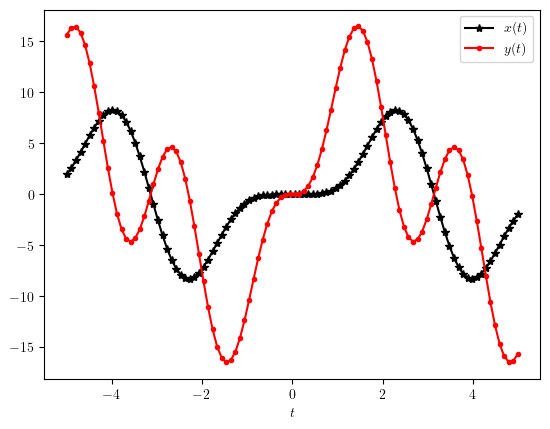

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

t = sp.symbols('t', positive=True)
X, Y = sp.symbols('X Y', cls=sp.Function)  # 定义符号函数

g = 40 * sp.sin(3 * t)  # 40sin(3t)用拉普拉斯变换，其他手动变换(x, y)

Lg = sp.laplace_transform(g, t, s)

eq1 = 2 * s**2 * X(s) + 6 * X(s) - 2 * Y(s)
eq2 = s**2 * Y(s) - 2 * X(s) + 2 * Y(s) - Lg[0]
eq = [eq1, eq2]  # 定义取拉式变换后的代数方程组
XYs = sp.solve(eq, (X(s), Y(s)))  # 求像函数
Xs = XYs[X(s)]
Ys = XYs[Y(s)]
# 因式分解
Xs = sp.factor(Xs)
Ys = sp.factor(Ys)
# 拉普拉斯逆变换
xt = sp.inverse_laplace_transform(Xs, s, t)
yt = sp.inverse_laplace_transform(Ys, s, t)
print(f"x(t)={xt}")
print(f"y(t)={yt}")

fx = sp.lambdify(t, xt, 'numpy')  # 转换为匿名函数
fy = sp.lambdify(t, yt, 'numpy')
t = np.linspace(-5, 5, 100)

plt.rcParams['text.usetex'] = True
plt.plot(t, fx(t), '*-k', label='$x(t)$')
plt.plot(t, fy(t), '.-r', label='$y(t)$')
plt.xlabel('$t$')
plt.legend()
plt.show()